In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED  = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEPHORA_COLOR   = "#E91E63"
ULTA_COLOR      = "#9C27B0"
TREATED_COLOR   = "#F44336"
CONTROL_COLOR   = "#4CAF50"
COUNTERFACT_COLOR = "#FF9800"
NEUTRAL_COLOR   = "#607D8B"
SPILLOVER_COLOR = "#FF5722"

In [2]:
sephora_seg = pd.read_csv(PROCESSED / "Sephora" / "sephora_segmentation.csv",
                           dtype={"product_id": str})
ulta_seg    = pd.read_csv(PROCESSED / "Ulta"    / "ulta_segmentation.csv",
                           dtype={"product_id": str})
matched     = pd.read_csv(PROCESSED / "Matched" / "matched_pairs.csv",
                           dtype={"sephora_product_id": str,
                                  "ulta_product_id":    str})
s_ts = pd.read_csv(PROCESSED / "Sephora" / "sephora_reviews_timeseries.csv",
                    dtype={"product_id": str})
u_ts = pd.read_csv(PROCESSED / "Ulta"    / "ulta_reviews_timeseries.csv",
                    dtype={"product_id": str})
s_clusters = pd.read_csv(PROCESSED / "Sephora" / "sephora_cluster_labels.csv",
                          dtype={"product_id": str})
u_clusters = pd.read_csv(PROCESSED / "Ulta"    / "ulta_cluster_labels.csv",
                          dtype={"product_id": str})

sephora_seg = sephora_seg.merge(s_clusters, on="product_id", how="left")
ulta_seg    = ulta_seg.merge(u_clusters,    on="product_id", how="left")
s_ts["platform"] = "Sephora"
u_ts["platform"] = "Ulta"

id_col_s  = "sephora_product_id"
id_col_u  = "ulta_product_id"
brand_col = "sephora_brand_normalized"

print(f"Sephora TS : {len(s_ts):,} rows  | {s_ts['product_id'].nunique():,} products")
print(f"Ulta TS    : {len(u_ts):,} rows  | {u_ts['product_id'].nunique():,} products")
print(f"Matched    : {len(matched):,} pairs")

Sephora TS : 28,693 rows  | 1,641 products
Ulta TS    : 137,858 rows  | 11,227 products
Matched    : 379 pairs


In [3]:
# A "treatment" is a month where negative_shock == 1.
# For each treated product-month, we need:
#   - pre-period: T-3 to T-1
#   - post-period: T+1 to T+4
#   - outcome: review_count (velocity) and avg_rating
#
# We apply DiD by pairing each treated product with a matched control
# (same platform, same segment, no shock in the same window).

def build_shock_panel(ts_df, seg_df, platform, n_pre=3, n_post=4):
    """
    For each product × shock-month, extract a balanced panel
    of pre/post observations and flag as treated.
    Returns long-format panel ready for DiD regression.
    """
    seg_col = "kmeans_weighted" if "kmeans_weighted" in seg_df.columns else None
    price_col = "price" if "price" in seg_df.columns else None

    ts_df = ts_df.copy().sort_values(["product_id", "year_month"])
    ts_df["t"] = ts_df.groupby("product_id").cumcount()

    # Products with at least one shock
    shocked = ts_df[ts_df["negative_shock"] == 1]["product_id"].unique()
    records = []

    for pid in shocked:
        prod_ts = ts_df[ts_df["product_id"] == pid].reset_index(drop=True)
        shock_rows = prod_ts.index[prod_ts["negative_shock"] == 1].tolist()

        for shock_idx in shock_rows:
            pre_start = shock_idx - n_pre
            post_end  = shock_idx + n_post + 1
            if pre_start < 0 or post_end > len(prod_ts):
                continue

            window = prod_ts.iloc[pre_start:post_end].copy()
            window["event_time"] = range(-n_pre, n_post + 1)
            window["shock_month"] = prod_ts.iloc[shock_idx]["year_month"]
            window["treated"]     = 1
            window["post"]        = (window["event_time"] >= 0).astype(int)
            records.append(window)

    if not records:
        return pd.DataFrame(), pd.DataFrame()

    treated_panel = pd.concat(records, ignore_index=True)

    # Attach segment info for matching
    if seg_col and seg_col in seg_df.columns:
        meta = seg_df[["product_id", seg_col] +
                      ([price_col] if price_col else [])].drop_duplicates("product_id")
        treated_panel = treated_panel.merge(meta, on="product_id", how="left")

    return treated_panel

s_treated = build_shock_panel(s_ts, sephora_seg, "Sephora")
u_treated = build_shock_panel(u_ts, ulta_seg,    "Ulta")

print(f"Sephora treated panel: {len(s_treated):,} rows  "
      f"| {s_treated['product_id'].nunique() if len(s_treated) else 0} products")
print(f"Ulta treated panel   : {len(u_treated):,} rows  "
      f"| {u_treated['product_id'].nunique() if len(u_treated) else 0} products")

Sephora treated panel: 30,432 rows  | 871 products
Ulta treated panel   : 92,824 rows  | 4082 products


In [4]:
# Match each shocked product to a never-shocked control product on:
#   - same segment (kmeans_weighted)
#   - similar pre-shock velocity (reviews_per_month)
#   - similar price
# Use nearest-neighbour matching in standardised feature space.

def match_controls(ts_df, seg_df, treated_pids, n_matches=1):
    """
    Returns a DataFrame of control product_ids matched to treated products.
    """
    seg_col   = "kmeans_weighted" if "kmeans_weighted" in seg_df.columns else None
    price_col = "price"           if "price"           in seg_df.columns else None

    # Never-shocked products
    shocked_set  = set(treated_pids)
    all_pids     = set(ts_df["product_id"].unique())
    control_pids = list(all_pids - shocked_set)

    # Feature: mean velocity, price, segment dummy
    def product_features(pids):
        feats = []
        for pid in pids:
            sub = ts_df[ts_df["product_id"] == pid]
            vel = sub["review_count"].mean()
            row = {"product_id": pid, "mean_velocity": vel}
            if price_col and seg_col:
                meta = seg_df[seg_df["product_id"] == pid]
                if len(meta):
                    row["price"]   = meta[price_col].iloc[0]
                    row["segment"] = meta[seg_col].iloc[0]
            feats.append(row)
        return pd.DataFrame(feats).fillna(0)

    t_feats = product_features(list(treated_pids))
    c_feats = product_features(control_pids)

    match_cols = [c for c in ["mean_velocity", "price", "segment"]
                  if c in t_feats.columns and c in c_feats.columns]
    if not match_cols:
        return pd.DataFrame()

    scaler  = StandardScaler()
    t_X = scaler.fit_transform(t_feats[match_cols])
    c_X = scaler.transform(c_feats[match_cols])

    nn = NearestNeighbors(n_neighbors=n_matches, metric="euclidean")
    nn.fit(c_X)
    distances, indices = nn.kneighbors(t_X)

    pairs = []
    for i, (treated_pid, idx_row) in enumerate(
        zip(t_feats["product_id"], indices)
    ):
        for j, ctrl_idx in enumerate(idx_row):
            pairs.append({
                "treated_pid": treated_pid,
                "control_pid": c_feats.iloc[ctrl_idx]["product_id"],
                "match_dist":  distances[i][j],
            })
    return pd.DataFrame(pairs)

s_shocked_pids = s_treated["product_id"].unique() if len(s_treated) else []
u_shocked_pids = u_treated["product_id"].unique() if len(u_treated) else []

s_matches = match_controls(s_ts, sephora_seg, s_shocked_pids)
u_matches = match_controls(u_ts, ulta_seg,    u_shocked_pids)

print(f"Sephora matched pairs: {len(s_matches):,}")
print(f"Ulta matched pairs   : {len(u_matches):,}")

Sephora matched pairs: 871
Ulta matched pairs   : 4,082


In [5]:
def build_did_panel(ts_df, treated_panel, matches, n_pre=3, n_post=4):
    """
    Combine treated + matched control observations into a single DiD panel.
    Columns: product_id, event_time, post, treated, review_count,
             avg_rating, avg_sentiment, shock_month
    """
    if len(treated_panel) == 0 or len(matches) == 0:
        return pd.DataFrame()

    # Build control panel aligned on the treated product's shock month
    control_records = []
    for _, row in matches.iterrows():
        t_pid = row["treated_pid"]
        c_pid = row["control_pid"]

        # Get shock months for this treated product
        shock_months = (treated_panel[treated_panel["product_id"] == t_pid]
                        ["shock_month"].unique())

        ctrl_ts = ts_df[ts_df["product_id"] == c_pid].sort_values("year_month")
        if len(ctrl_ts) == 0:
            continue

        for sm in shock_months:
            # Find the position in control TS corresponding to the shock month
            ym_list = ctrl_ts["year_month"].tolist()
            if sm not in ym_list:
                # Use temporal position instead
                t_ym_list = (treated_panel[treated_panel["product_id"] == t_pid]
                             ["year_month"].tolist())
                ref_idx   = len(t_ym_list) // 2
            else:
                ref_idx = ym_list.index(sm)

            pre_start = ref_idx - n_pre
            post_end  = ref_idx + n_post + 1
            if pre_start < 0 or post_end > len(ctrl_ts):
                continue

            window = ctrl_ts.iloc[pre_start:post_end].copy()
            window["event_time"] = range(-n_pre, n_post + 1)
            window["shock_month"] = sm
            window["treated"]     = 0
            window["post"]        = (window["event_time"] >= 0).astype(int)
            control_records.append(window)

    if not control_records:
        return pd.DataFrame()

    ctrl_panel = pd.concat(control_records, ignore_index=True)
    combined   = pd.concat([
        treated_panel[["product_id", "event_time", "post", "treated",
                        "review_count", "avg_rating", "avg_sentiment",
                        "shock_month"]],
        ctrl_panel[["product_id", "event_time", "post", "treated",
                    "review_count", "avg_rating", "avg_sentiment",
                    "shock_month"]],
    ], ignore_index=True)

    return combined

s_did = build_did_panel(s_ts, s_treated, s_matches)
u_did = build_did_panel(u_ts, u_treated, u_matches)

print(f"Sephora DiD panel: {len(s_did):,} rows")
print(f"Ulta DiD panel   : {len(u_did):,} rows")

Sephora DiD panel: 35,040 rows
Ulta DiD panel   : 107,416 rows


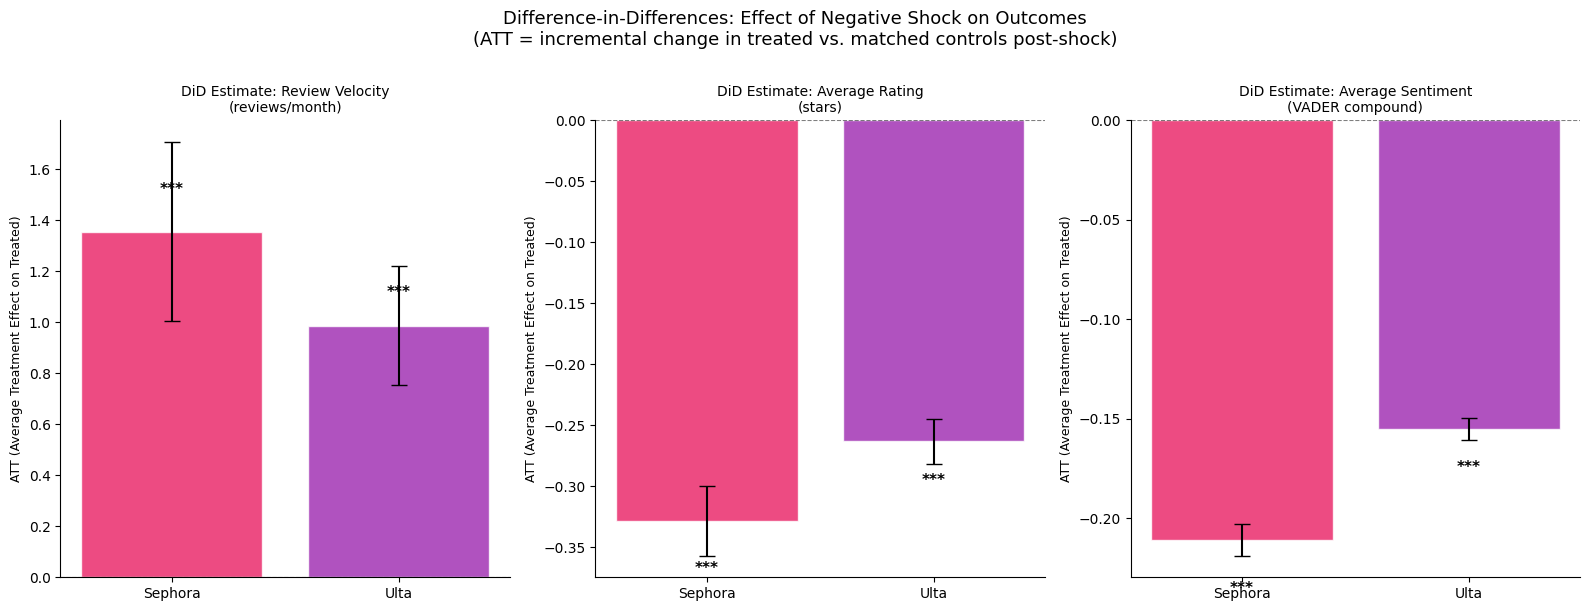

In [6]:
def run_did(panel, outcome, platform):
    """
    Estimate DiD: outcome ~ treated * post + treated + post + FE(product_id)
    Returns ATT (average treatment effect on treated) and SE.
    """
    if len(panel) == 0:
        return None

    sub = panel[["product_id", "event_time", "post", "treated",
                 outcome, "shock_month"]].dropna()
    if len(sub) < 20:
        return None

    sub["did"] = sub["treated"] * sub["post"]

    # Two-way FE via demeaning
    sub["outcome_dm"] = sub[outcome] - sub.groupby("product_id")[outcome].transform("mean")
    sub["did_dm"]     = sub["did"]   - sub.groupby("product_id")["did"].transform("mean")
    sub["post_dm"]    = sub["post"]  - sub.groupby("product_id")["post"].transform("mean")

    try:
        X   = add_constant(sub[["did_dm", "post_dm"]])
        res = sm.OLS(sub["outcome_dm"], X).fit(cov_type="HC3")
        att = res.params.get("did_dm", np.nan)
        se  = res.bse.get("did_dm", np.nan)
        p   = res.pvalues.get("did_dm", np.nan)
        return {"att": att, "se": se, "p": p,
                "n_treated": sub[sub["treated"] == 1]["product_id"].nunique(),
                "n_obs": len(sub)}
    except Exception as e:
        print(f"DiD failed for {platform} {outcome}: {e}")
        return None

# Run DiD for both outcomes on both platforms
did_results = {}
for platform, panel in [("Sephora", s_did), ("Ulta", u_did)]:
    for outcome in ["review_count", "avg_rating", "avg_sentiment"]:
        key = f"{platform}_{outcome}"
        did_results[key] = run_did(panel, outcome, platform)

# Plot DiD estimates
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
outcomes  = ["review_count", "avg_rating", "avg_sentiment"]
labels    = ["Review Velocity\n(reviews/month)",
             "Average Rating\n(stars)",
             "Average Sentiment\n(VADER compound)"]

for ax, outcome, label in zip(axes, outcomes, labels):
    platforms = ["Sephora", "Ulta"]
    atts = [did_results.get(f"{p}_{outcome}", {}) or {} for p in platforms]
    att_vals = [r.get("att", np.nan) for r in atts]
    se_vals  = [r.get("se",  np.nan) for r in atts]
    p_vals   = [r.get("p",   1.0)    for r in atts]
    colors   = [SEPHORA_COLOR, ULTA_COLOR]

    bars = ax.bar(platforms, att_vals, yerr=se_vals,
                  color=colors, alpha=0.8, capsize=6,
                  edgecolor="white", error_kw={"elinewidth": 1.5})
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

    for bar, p, att in zip(bars, p_vals, att_vals):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else \
              "*" if p < 0.05 else "ns"
        if not np.isnan(att):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    att + (abs(att) * 0.1 if att >= 0 else -abs(att) * 0.1),
                    sig, ha="center", va="bottom" if att >= 0 else "top",
                    fontsize=11, fontweight="bold")

    ax.set_title(f"DiD Estimate: {label}", fontsize=10)
    ax.set_ylabel("ATT (Average Treatment Effect on Treated)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Difference-in-Differences: Effect of Negative Shock on Outcomes\n"
             "(ATT = incremental change in treated vs. matched controls post-shock)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.3_did_estimates.png", dpi=150, bbox_inches="tight")
plt.show()

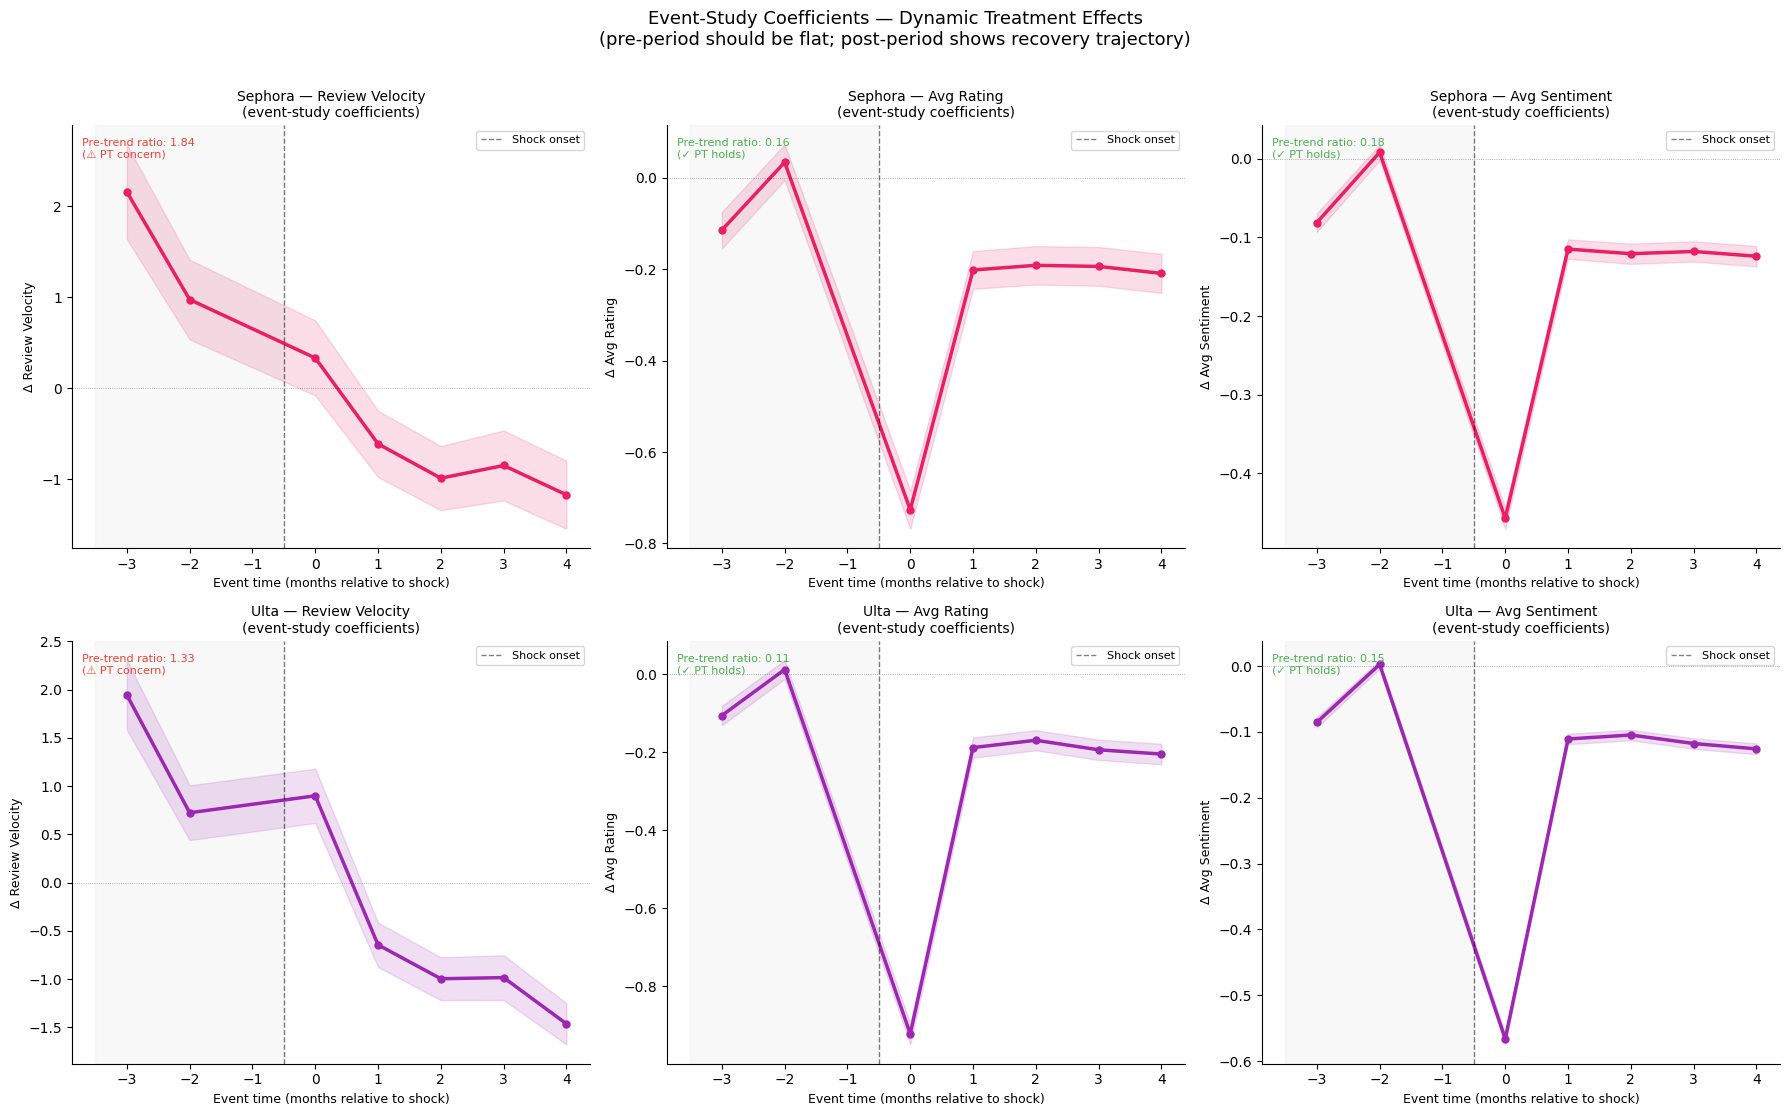

In [7]:
# Estimate separate DiD coefficients for each event_time period.
# Pre-period coefficients should be near zero (parallel trends).
# Post-period coefficients reveal the dynamic treatment path.

def event_study_coeffs(panel, outcome):
    if len(panel) == 0:
        return None
    sub = panel[["product_id", "event_time", "post", "treated",
                 outcome]].dropna()
    if len(sub) < 30:
        return None

    # Create event-time × treated dummies (omit t=-1 as reference)
    event_times = sorted(sub["event_time"].unique())
    ref_time    = -1
    coeffs, ses, ts = {}, {}, {}

    for et in event_times:
        if et == ref_time:
            continue
        sub[f"d_{et}"] = ((sub["event_time"] == et) & (sub["treated"] == 1)).astype(int)

    dummy_cols = [f"d_{et}" for et in event_times if et != ref_time]
    if not dummy_cols:
        return None

    sub["outcome_dm"] = sub[outcome] - sub.groupby("product_id")[outcome].transform("mean")
    X = sub[dummy_cols].copy()
    X = X - X.groupby(sub["product_id"]).transform("mean")

    try:
        res = sm.OLS(sub["outcome_dm"], add_constant(X)).fit(cov_type="HC3")
        for et, col in zip([t for t in event_times if t != ref_time], dummy_cols):
            coeffs[et] = res.params.get(col, np.nan)
            ses[et]    = res.bse.get(col,    np.nan)
    except Exception:
        return None

    return {"event_times": [t for t in event_times if t != ref_time],
            "coeffs":      [coeffs[t] for t in event_times if t != ref_time],
            "ses":         [ses[t]    for t in event_times if t != ref_time]}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
outcomes  = ["review_count", "avg_rating", "avg_sentiment"]

for row, (platform, panel, color) in enumerate([
    ("Sephora", s_did, SEPHORA_COLOR),
    ("Ulta",    u_did, ULTA_COLOR),
]):
    for col_idx, (outcome, label) in enumerate(zip(
        outcomes, ["Review Velocity", "Avg Rating", "Avg Sentiment"]
    )):
        ax     = axes[row][col_idx]
        result = event_study_coeffs(panel, outcome)

        if result is None:
            ax.text(0.5, 0.5, "Insufficient data",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{platform} — {label}", fontsize=10)
            continue

        ets    = result["event_times"]
        coeffs = np.array(result["coeffs"])
        ses    = np.array(result["ses"])

        ax.fill_between(ets, coeffs - 1.96 * ses, coeffs + 1.96 * ses,
                        color=color, alpha=0.15)
        ax.plot(ets, coeffs, color=color, lw=2.5, marker="o", markersize=5)
        ax.axvline(-0.5, color="black", lw=1, ls="--", alpha=0.5,
                   label="Shock onset")
        ax.axhline(0,    color="black", lw=0.6, ls=":",  alpha=0.4)

        # Shade pre-period — should be flat if parallel trends holds
        pre_ets    = [e for e in ets if e < 0]
        pre_coeffs = coeffs[:len(pre_ets)]
        pre_max    = max(abs(pre_coeffs)) if len(pre_coeffs) else 0
        post_max   = max(abs(coeffs[len(pre_ets):])) if len(ets) > len(pre_ets) else 0
        pt_ratio   = pre_max / (post_max + 1e-9)

        ax.axvspan(min(ets) - 0.5, -0.5, color="gray", alpha=0.05)
        ax.text(0.02, 0.97,
                f"Pre-trend ratio: {pt_ratio:.2f}\n"
                f"({'✓ PT holds' if pt_ratio < 0.3 else '⚠ PT concern'})",
                transform=ax.transAxes, fontsize=8, va="top",
                color=CONTROL_COLOR if pt_ratio < 0.3 else TREATED_COLOR)

        ax.set_xlabel("Event time (months relative to shock)", fontsize=9)
        ax.set_ylabel(f"Δ {label}", fontsize=9)
        ax.set_title(f"{platform} — {label}\n(event-study coefficients)",
                     fontsize=10)
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Event-Study Coefficients — Dynamic Treatment Effects\n"
             "(pre-period should be flat; post-period shows recovery trajectory)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.3_event_study_coefficients.png",
            dpi=150, bbox_inches="tight")
plt.show()

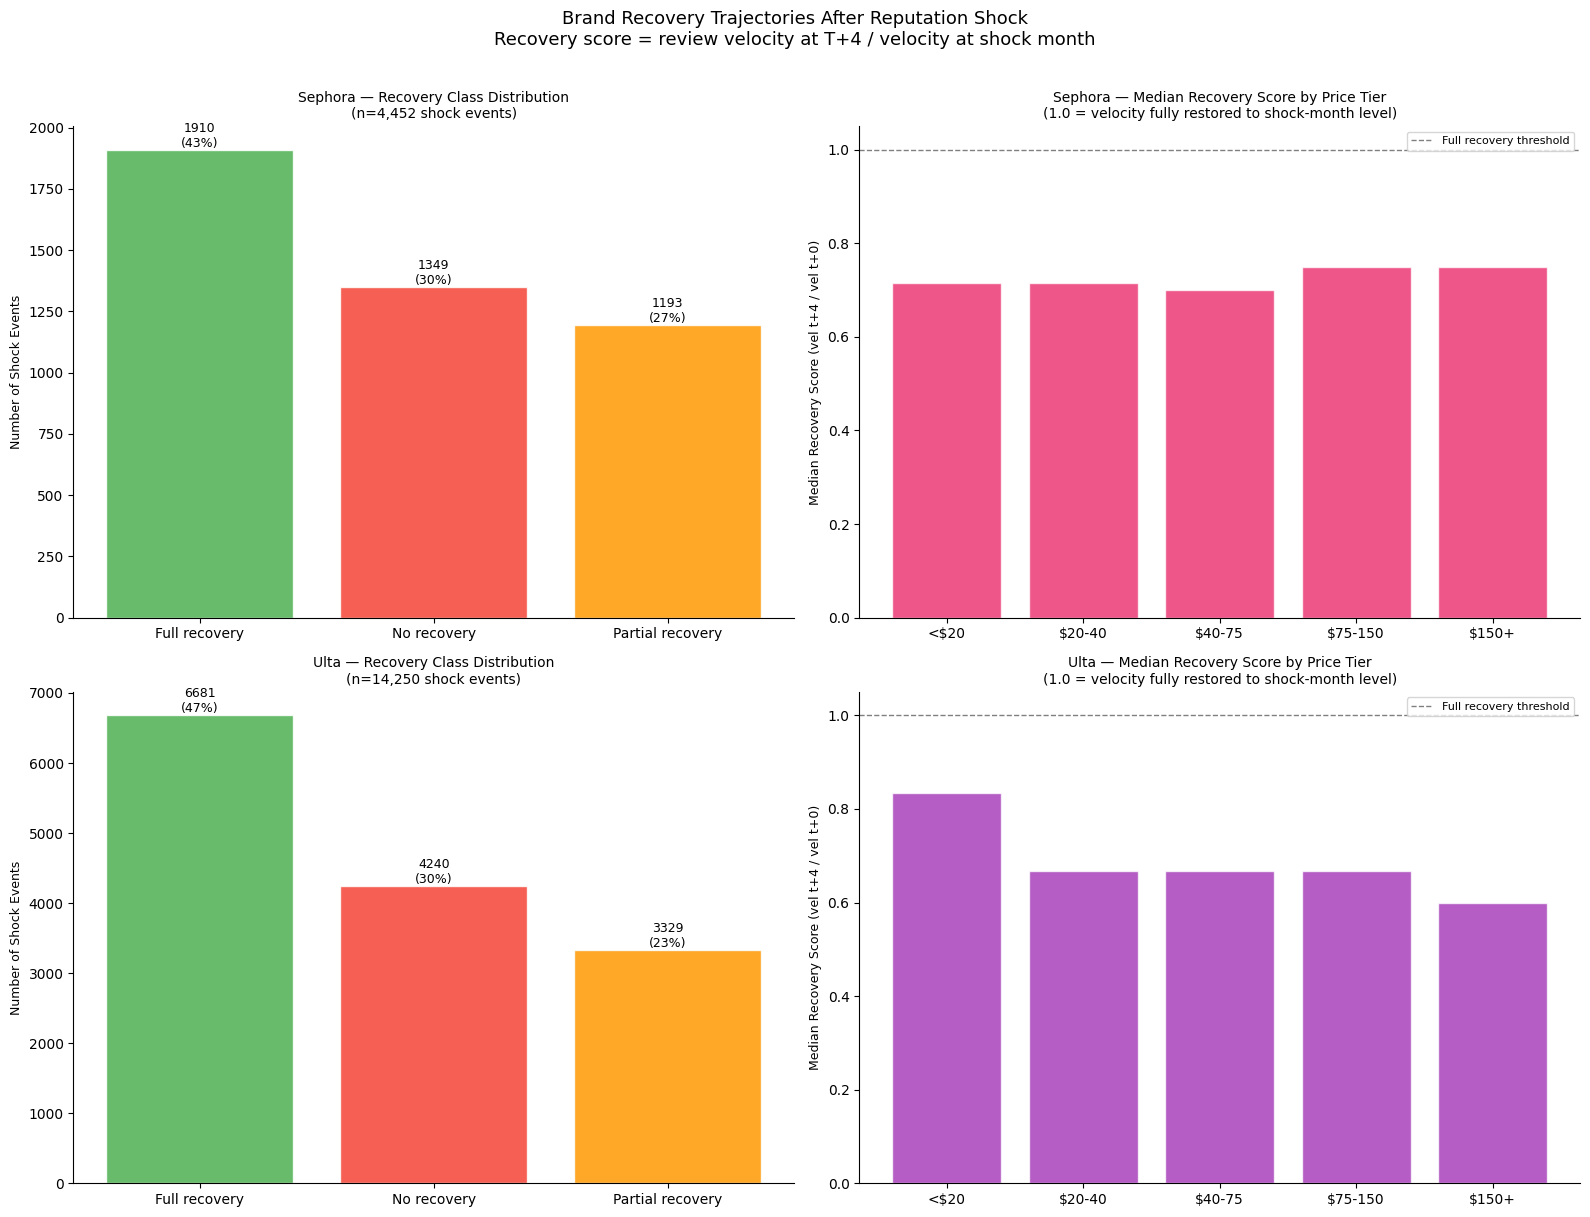

In [8]:
# For each shocked brand, compute a recovery score:
#   velocity at T+4 / velocity at T+0 (shock month)
# Classify as: Full recovery (>1.0), Partial (0.5–1.0), No recovery (<0.5)
# Compare recovery rates across platforms and price tiers.

def brand_recovery(ts_df, seg_df, n_post=4):
    seg_col   = "kmeans_weighted" if "kmeans_weighted" in seg_df.columns else None
    price_col = "price"           if "price"           in seg_df.columns else None
    brand_col = "brand_normalized" if "brand_normalized" in seg_df.columns \
                else "brand"

    ts_df = ts_df.sort_values(["product_id", "year_month"])
    meta  = seg_df[["product_id"] +
                   [c for c in [brand_col, seg_col, price_col] if c]
                   ].drop_duplicates("product_id")

    records = []
    for pid, grp in ts_df.groupby("product_id"):
        grp = grp.reset_index(drop=True)
        shock_idx_list = grp.index[grp["negative_shock"] == 1].tolist()
        for si in shock_idx_list:
            if si + n_post >= len(grp):
                continue
            vel_shock    = grp.iloc[si]["review_count"]
            vel_recovery = grp.iloc[si + n_post]["review_count"]
            rat_shock    = grp.iloc[si]["avg_rating"]
            rat_recovery = grp.iloc[si + n_post]["avg_rating"]

            if vel_shock > 0:
                rec_score = vel_recovery / vel_shock
            else:
                rec_score = np.nan

            records.append({
                "product_id":      pid,
                "shock_month":     grp.iloc[si]["year_month"],
                "vel_shock":       vel_shock,
                "vel_recovery":    vel_recovery,
                "recovery_score":  rec_score,
                "rating_delta":    rat_recovery - rat_shock if
                                   not np.isnan(rat_shock) and
                                   not np.isnan(rat_recovery) else np.nan,
            })

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df = df.merge(meta, on="product_id", how="left")

    def classify(r):
        if np.isnan(r): return "Unknown"
        if r >= 1.0:    return "Full recovery"
        if r >= 0.5:    return "Partial recovery"
        return "No recovery"

    df["recovery_class"] = df["recovery_score"].apply(classify)
    return df

s_recovery = brand_recovery(s_ts, sephora_seg)
u_recovery = brand_recovery(u_ts, ulta_seg)

REC_COLORS = {
    "Full recovery":    CONTROL_COLOR,
    "Partial recovery": COUNTERFACT_COLOR,
    "No recovery":      TREATED_COLOR,
    "Unknown":          NEUTRAL_COLOR,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (platform, rec_df, seg_df, color) in enumerate([
    ("Sephora", s_recovery, sephora_seg, SEPHORA_COLOR),
    ("Ulta",    u_recovery, ulta_seg,    ULTA_COLOR),
]):
    if len(rec_df) == 0:
        continue

    # Panel left: recovery class distribution
    ax = axes[row][0]
    counts = rec_df["recovery_class"].value_counts()
    bar_colors = [REC_COLORS.get(c, NEUTRAL_COLOR) for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=bar_colors,
                  alpha=0.85, edgecolor="white")
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                cnt + 0.5, f"{cnt}\n({cnt/len(rec_df):.0%})",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{platform} — Recovery Class Distribution\n"
                 f"(n={len(rec_df):,} shock events)", fontsize=10)
    ax.set_ylabel("Number of Shock Events", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    # Panel right: recovery score by price tier
    ax2 = axes[row][1]
    price_col = "price" if "price" in rec_df.columns else None
    if price_col:
        rec_df["price_tier"] = pd.cut(
            rec_df[price_col],
            bins=[0, 20, 40, 75, 150, np.inf],
            labels=["<$20", "$20-40", "$40-75", "$75-150", "$150+"]
        )
        tier_stats = (rec_df.groupby("price_tier", observed=True)["recovery_score"]
                      .agg(["median", "mean", "std", "count"])
                      .reset_index())
        ax2.bar(tier_stats["price_tier"].astype(str),
                tier_stats["median"], color=color,
                alpha=0.75, edgecolor="white")
        ax2.axhline(1.0, color="black", lw=1, ls="--", alpha=0.5,
                    label="Full recovery threshold")
        ax2.set_title(f"{platform} — Median Recovery Score by Price Tier\n"
                      "(1.0 = velocity fully restored to shock-month level)",
                      fontsize=10)
        ax2.set_ylabel("Median Recovery Score (vel t+4 / vel t+0)", fontsize=9)
        ax2.legend(fontsize=8)
        ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Brand Recovery Trajectories After Reputation Shock\n"
             "Recovery score = review velocity at T+4 / velocity at shock month",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.3_recovery_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()

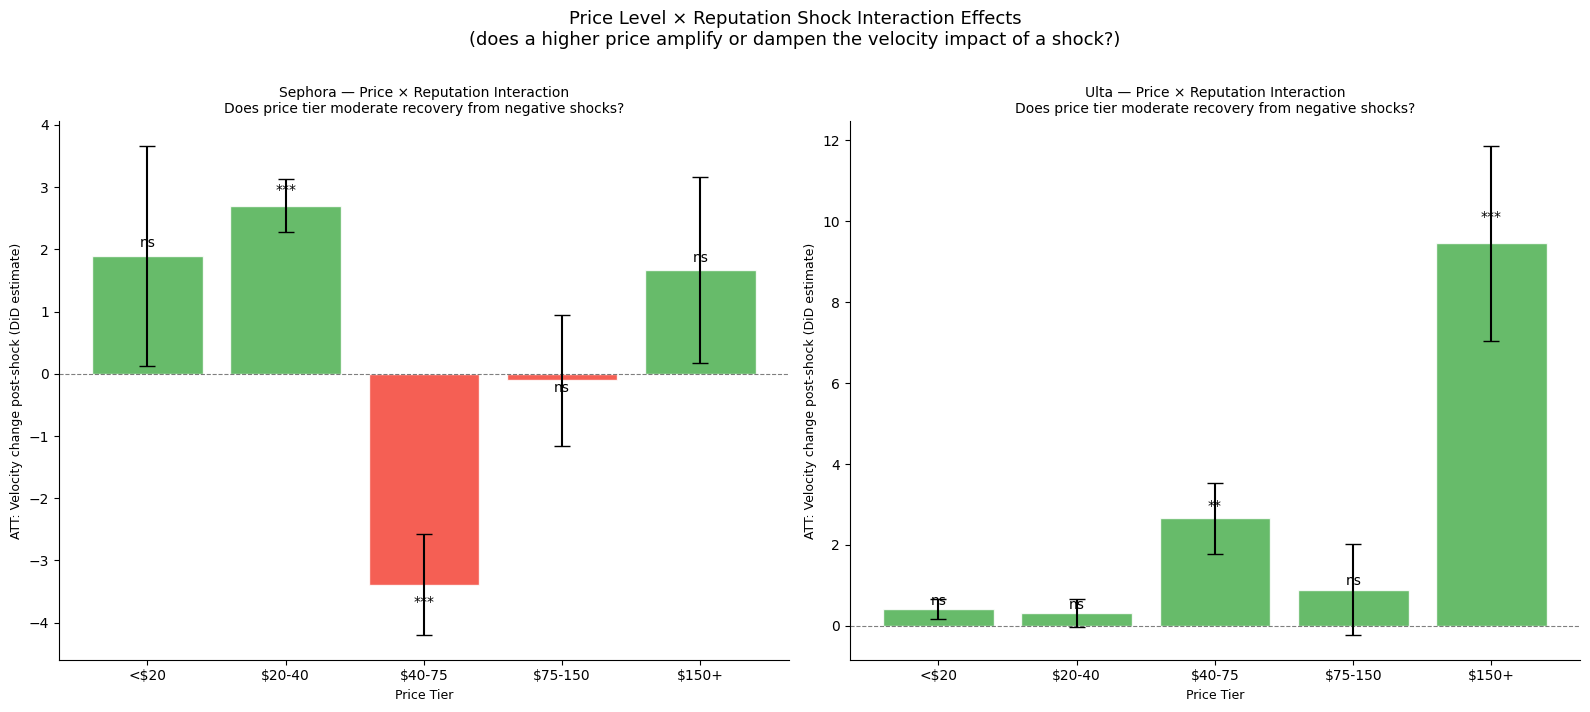

In [9]:
# Does a higher price amplify or dampen the effect of a reputation shock?
# Run interacted DiD: outcome ~ treated*post*price_tier + FEs

def price_interaction_did(panel, seg_df, outcome="review_count"):
    if len(panel) == 0:
        return pd.DataFrame()

    price_col = "price" if "price" in seg_df.columns else None
    if price_col is None:
        return pd.DataFrame()

    meta = seg_df[["product_id", price_col]].drop_duplicates("product_id")
    pan  = panel.merge(meta, on="product_id", how="left")
    pan  = pan.dropna(subset=[outcome, price_col])

    pan["price_tier"] = pd.cut(
        pan[price_col],
        bins=[0, 20, 40, 75, 150, np.inf],
        labels=["<$20", "$20-40", "$40-75", "$75-150", "$150+"]
    )
    pan["did"] = pan["treated"] * pan["post"]

    results = []
    for tier in pan["price_tier"].cat.categories:
        sub = pan[pan["price_tier"] == tier].copy()
        if len(sub) < 20 or sub["treated"].sum() == 0:
            continue
        sub["outcome_dm"] = (sub[outcome] -
                             sub.groupby("product_id")[outcome].transform("mean"))
        sub["did_dm"]     = (sub["did"] -
                             sub.groupby("product_id")["did"].transform("mean"))
        sub["post_dm"]    = (sub["post"] -
                             sub.groupby("product_id")["post"].transform("mean"))
        try:
            X   = add_constant(sub[["did_dm", "post_dm"]])
            res = sm.OLS(sub["outcome_dm"], X).fit(cov_type="HC3")
            att = res.params.get("did_dm", np.nan)
            se  = res.bse.get("did_dm",  np.nan)
            p   = res.pvalues.get("did_dm", 1.0)
            results.append({"price_tier": str(tier), "att": att,
                            "se": se, "p": p, "n": len(sub)})
        except Exception:
            continue

    return pd.DataFrame(results)

s_price_did = price_interaction_did(s_did, sephora_seg)
u_price_did = price_interaction_did(u_did, ulta_seg)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (platform, price_did, color) in [
    (axes[0], ("Sephora", s_price_did, SEPHORA_COLOR)),
    (axes[1], ("Ulta",    u_price_did, ULTA_COLOR)),
]:
    if len(price_did) == 0:
        ax.text(0.5, 0.5, "Insufficient data",
                ha="center", va="center", transform=ax.transAxes)
        continue

    bar_colors = [CONTROL_COLOR if a > 0 else TREATED_COLOR
                  for a in price_did["att"]]
    bars = ax.bar(price_did["price_tier"], price_did["att"],
                  yerr=price_did["se"], color=bar_colors,
                  alpha=0.85, capsize=6, edgecolor="white",
                  error_kw={"elinewidth": 1.5})

    for bar, row in zip(bars, price_did.itertuples()):
        sig = "***" if row.p < 0.001 else "**" if row.p < 0.01 else \
              "*" if row.p < 0.05 else "ns"
        ax.text(bar.get_x() + bar.get_width() / 2,
                row.att + (abs(row.att) * 0.05 if row.att >= 0
                           else -abs(row.att) * 0.05),
                sig, ha="center",
                va="bottom" if row.att >= 0 else "top", fontsize=10)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Price Tier", fontsize=9)
    ax.set_ylabel("ATT: Velocity change post-shock (DiD estimate)", fontsize=9)
    ax.set_title(f"{platform} — Price × Reputation Interaction\n"
                 "Does price tier moderate recovery from negative shocks?",
                 fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Price Level × Reputation Shock Interaction Effects\n"
             "(does a higher price amplify or dampen the velocity impact of a shock?)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.3_price_reputation_interaction.png",
            dpi=150, bbox_inches="tight")
plt.show()

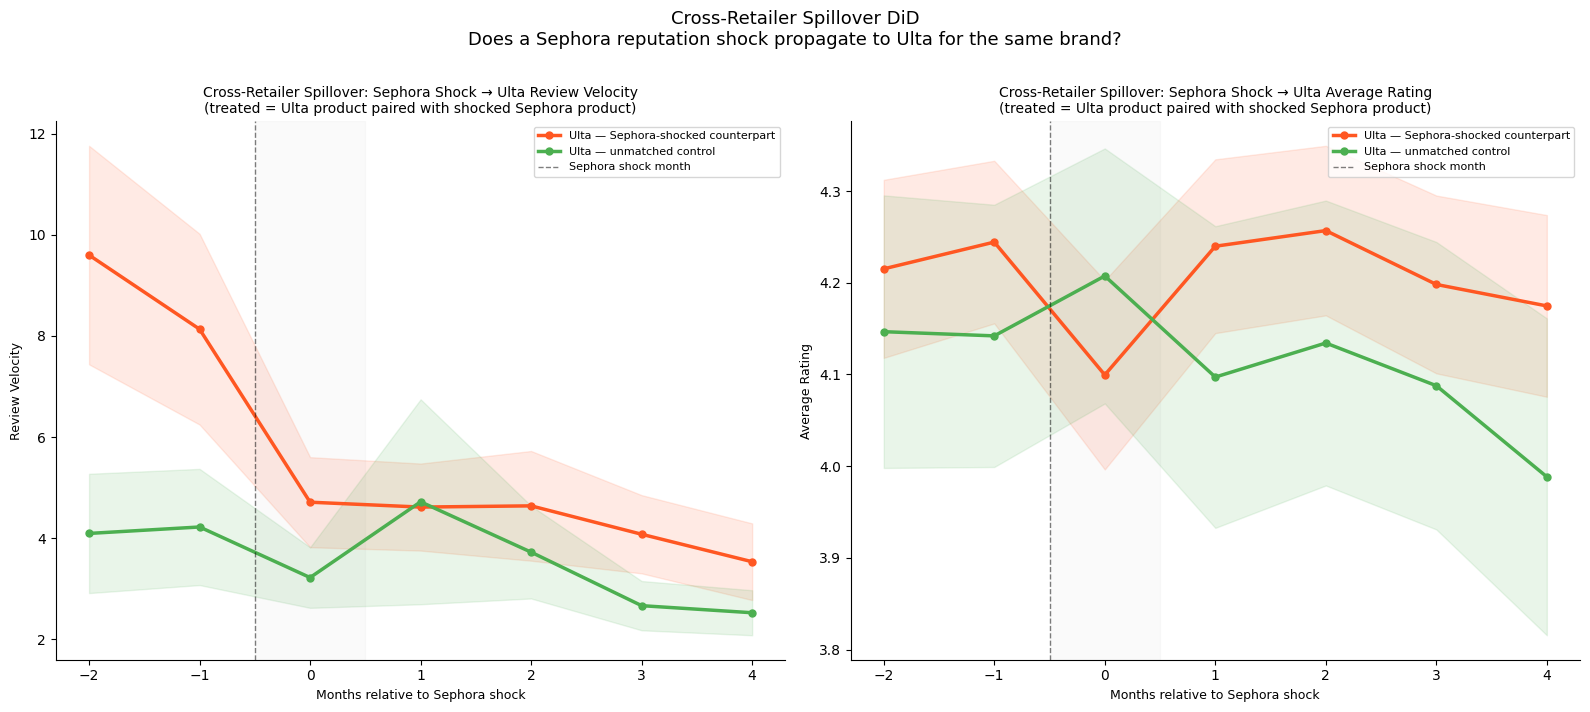

In [12]:
# For matched pairs: when a Sephora product is shocked, does its Ulta counterpart
# show a measurable velocity change relative to unmatched Ulta controls?

if len(matched) > 0 and len(s_ts) > 0 and len(u_ts) > 0:
    # Identify Sephora-shocked products that have an Ulta counterpart
    s_shocked_set = set(s_ts[s_ts["negative_shock"] == 1]["product_id"].unique())
    matched_shocked = matched[matched[id_col_s].isin(s_shocked_set)]

    spillover_records = []
    for _, pair in matched_shocked.iterrows():
        s_pid = pair[id_col_s]
        u_pid = pair[id_col_u]

        # Sephora shock months for this product
        s_shocks = (s_ts[(s_ts["product_id"] == s_pid) &
                         (s_ts["negative_shock"] == 1)]["year_month"].tolist())

        u_prod_ts = u_ts[u_ts["product_id"] == u_pid].sort_values("year_month")
        if len(u_prod_ts) == 0:
            continue

        ym_list = u_prod_ts["year_month"].tolist()
        for sm in s_shocks:
            if sm not in ym_list:
                continue
            ref_idx  = ym_list.index(sm)
            pre_s, post_e = ref_idx - 2, ref_idx + 5
            if pre_s < 0 or post_e > len(u_prod_ts):
                continue
            window = u_prod_ts.iloc[pre_s:post_e].copy()
            window["event_time"]   = range(-2, 5)
            window["treated"]      = 1   # Ulta counterpart of Sephora shock
            window["post"]         = (window["event_time"] >= 0).astype(int)
            window["shock_month"]  = sm
            spillover_records.append(window)

    # Control: Ulta products with NO shocked Sephora counterpart
    u_unmatched = set(u_ts["product_id"].unique()) - \
                  set(matched[id_col_u].unique())
    ctrl_records = []
    for u_pid in list(u_unmatched)[:500]:   # sample for speed
        u_prod_ts = u_ts[u_ts["product_id"] == u_pid].sort_values("year_month")
        if len(u_prod_ts) < 7:
            continue
        mid = len(u_prod_ts) // 2
        window = u_prod_ts.iloc[mid-2:mid+5].copy()
        if len(window) < 7:
            continue
        window["event_time"]  = range(-2, 5)
        window["treated"]     = 0
        window["post"]        = (window["event_time"] >= 0).astype(int)
        window["shock_month"] = window["year_month"].iloc[2]
        ctrl_records.append(window)

    if spillover_records and ctrl_records:
        sp_panel = pd.concat(spillover_records + ctrl_records, ignore_index=True)

        # Event-study plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # Panel 1: mean velocity by event_time × treatment
        for ax_panel, outcome, label in [
            (axes[0], "review_count", "Review Velocity"),
            (axes[1], "avg_rating",   "Average Rating"),
        ]:
            for grp_val, grp_label, c in [
                (1, "Ulta — Sephora-shocked counterpart", SPILLOVER_COLOR),
                (0, "Ulta — unmatched control",           CONTROL_COLOR),
            ]:
                sub = sp_panel[sp_panel["treated"] == grp_val]
                et_mean = (sub.groupby("event_time")[outcome]
                           .agg(["mean", "sem"]).reset_index())
                ax_panel.plot(et_mean["event_time"], et_mean["mean"],
                              color=c, lw=2.5, marker="o", markersize=5,
                              label=grp_label)
                ax_panel.fill_between(
                    et_mean["event_time"],
                    et_mean["mean"] - 1.96 * et_mean["sem"],
                    et_mean["mean"] + 1.96 * et_mean["sem"],
                    color=c, alpha=0.12
                )

            ax_panel.axvline(-0.5, color="black", lw=1, ls="--",
                             alpha=0.5, label="Sephora shock month")
            ax_panel.axvspan(-0.5, 0.5, color="gray", alpha=0.04)
            ax_panel.set_xlabel("Months relative to Sephora shock", fontsize=9)
            ax_panel.set_ylabel(label, fontsize=9)
            ax_panel.set_title(f"Cross-Retailer Spillover: Sephora Shock → Ulta {label}\n"
                               "(treated = Ulta product paired with shocked Sephora product)",
                               fontsize=10)
            ax_panel.legend(fontsize=8)
            ax_panel.spines[["top", "right"]].set_visible(False)

        fig.suptitle("Cross-Retailer Spillover DiD\n"
                     "Does a Sephora reputation shock propagate to Ulta for the same brand?",
                     fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "3.3_spillover_did.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

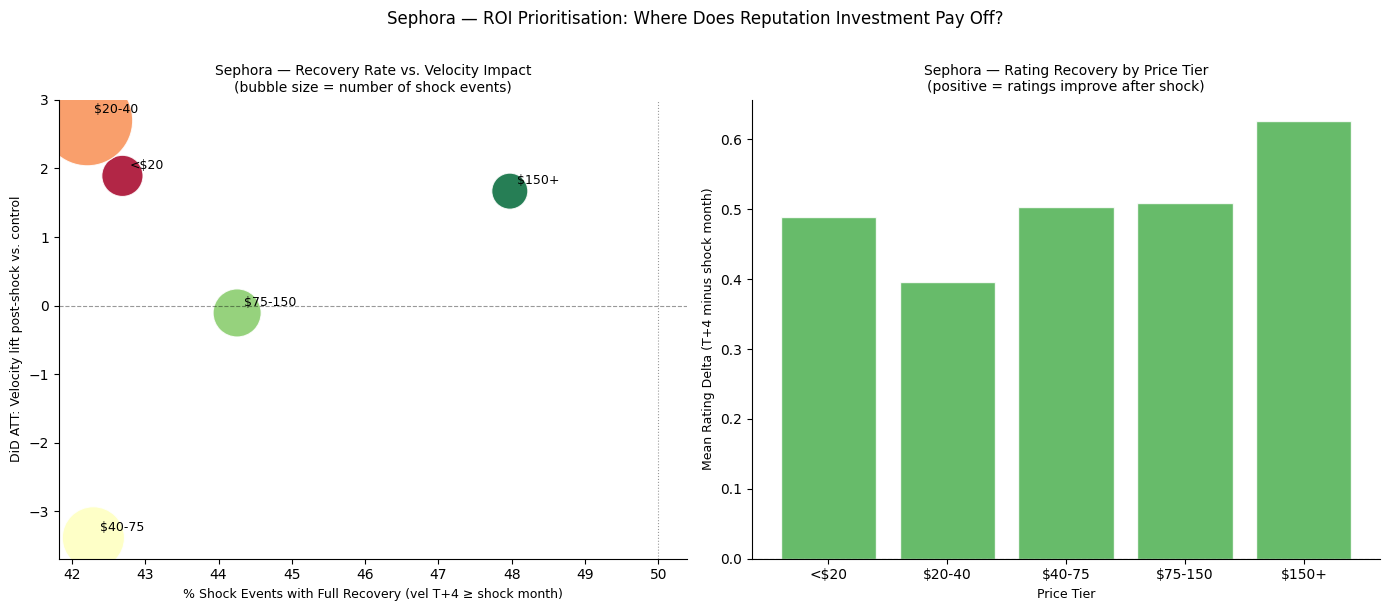

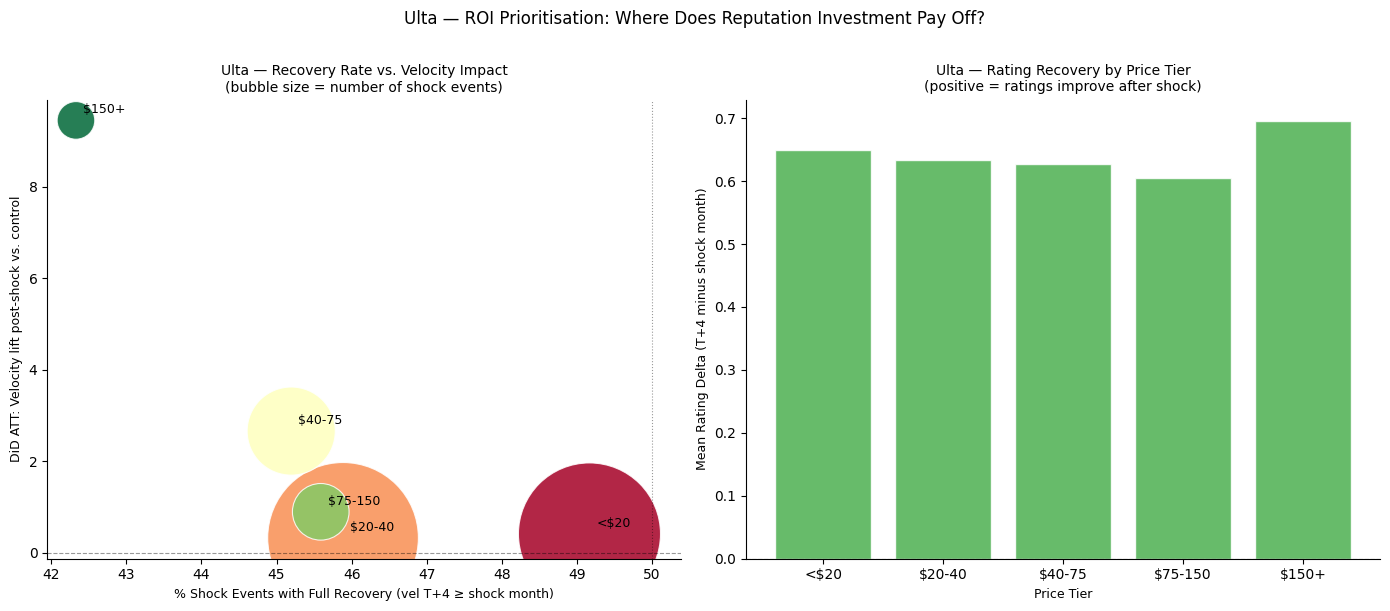

In [13]:
# Synthesise DiD + recovery results into a per-platform ROI action matrix.
# For each product segment × price tier, estimate:
#   Expected velocity loss from shock (DiD ATT)
#   Expected recovery time (from recovery trajectories)
#   Implied ROI of pre-emptive reputation investment vs. reactive recovery

for platform, rec_df, price_did_df, color in [
    ("Sephora", s_recovery, s_price_did, SEPHORA_COLOR),
    ("Ulta",    u_recovery, u_price_did, ULTA_COLOR),
]:
    if len(rec_df) == 0 or "price" not in rec_df.columns:
        continue

    rec_df["price_tier"] = pd.cut(
        rec_df["price"],
        bins=[0, 20, 40, 75, 150, np.inf],
        labels=["<$20", "$20-40", "$40-75", "$75-150", "$150+"]
    )

    tier_summary = (
        rec_df.groupby("price_tier", observed=True)
        .agg(
            n_shocks          = ("recovery_score", "count"),
            median_recovery   = ("recovery_score", "median"),
            pct_full_recovery = ("recovery_class",
                                 lambda x: (x == "Full recovery").mean()),
            mean_rating_delta = ("rating_delta",  "mean"),
        )
        .reset_index()
    )

    if len(price_did_df):
        tier_summary = tier_summary.merge(
            price_did_df[["price_tier", "att"]].rename(
                columns={"att": "did_att"}),
            on="price_tier", how="left"
        )
    else:
        tier_summary["did_att"] = np.nan

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: recovery rate × DiD ATT bubble chart
    ax = axes[0]
    valid = tier_summary.dropna(subset=["median_recovery"])
    sc = ax.scatter(
        valid["pct_full_recovery"] * 100,
        valid["did_att"].fillna(0),
        s=valid["n_shocks"] * 2 + 30,
        c=range(len(valid)), cmap="RdYlGn", alpha=0.85,
        edgecolors="white", linewidths=0.8
    )
    for _, row in valid.iterrows():
        ax.annotate(str(row["price_tier"]),
                    xy=(row["pct_full_recovery"] * 100,
                        row["did_att"] if not np.isnan(row["did_att"]) else 0),
                    xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
    ax.axvline(50, color="black", lw=0.8, ls=":", alpha=0.4)
    ax.set_xlabel("% Shock Events with Full Recovery (vel T+4 ≥ shock month)",
                  fontsize=9)
    ax.set_ylabel("DiD ATT: Velocity lift post-shock vs. control", fontsize=9)
    ax.set_title(f"{platform} — Recovery Rate vs. Velocity Impact\n"
                 "(bubble size = number of shock events)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    # Panel 2: rating delta by tier
    ax2 = axes[1]
    rating_colors = [CONTROL_COLOR if v > 0 else TREATED_COLOR
                     for v in tier_summary["mean_rating_delta"].fillna(0)]
    ax2.bar(tier_summary["price_tier"].astype(str),
            tier_summary["mean_rating_delta"].fillna(0),
            color=rating_colors, alpha=0.85, edgecolor="white")
    ax2.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax2.set_xlabel("Price Tier", fontsize=9)
    ax2.set_ylabel("Mean Rating Delta (T+4 minus shock month)", fontsize=9)
    ax2.set_title(f"{platform} — Rating Recovery by Price Tier\n"
                  "(positive = ratings improve after shock)", fontsize=10)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"{platform} — ROI Prioritisation: Where Does Reputation Investment Pay Off?",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"3.3_roi_matrix_{platform.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [14]:
print("  3.3  QUASI-EXPERIMENTAL CAUSAL ATTRIBUTION — SUMMARY")

print("\nDiD estimates (ATT = average treatment effect on treated):")
for key, result in did_results.items():
    if result:
        sig = ("***" if result["p"] < 0.001 else "**" if result["p"] < 0.01
               else "*" if result["p"] < 0.05 else "ns")
        print(f"  {key:<35}  ATT={result['att']:+.3f}  SE={result['se']:.3f}"
              f"  p={result['p']:.3f} {sig}  "
              f"(n_treated={result['n_treated']})")

print("\nRecovery trajectory summary:")
for platform, rec_df in [("Sephora", s_recovery), ("Ulta", u_recovery)]:
    if len(rec_df) == 0:
        continue
    counts = rec_df["recovery_class"].value_counts()
    print(f"\n  {platform} (n={len(rec_df):,} shock events):")
    for cls, cnt in counts.items():
        print(f"    {cls:<20} {cnt:>5}  ({cnt/len(rec_df):.1%})")
    print(f"    Median recovery score : "
          f"{rec_df['recovery_score'].median():.2f}")
    print(f"    Mean rating delta T+4 : "
          f"{rec_df['rating_delta'].mean():+.3f} stars")

  3.3  QUASI-EXPERIMENTAL CAUSAL ATTRIBUTION — SUMMARY

DiD estimates (ATT = average treatment effect on treated):
  Sephora_review_count                 ATT=+1.356  SE=0.351  p=0.000 ***  (n_treated=871)
  Sephora_avg_rating                   ATT=-0.328  SE=0.029  p=0.000 ***  (n_treated=871)
  Sephora_avg_sentiment                ATT=-0.211  SE=0.008  p=0.000 ***  (n_treated=871)
  Ulta_review_count                    ATT=+0.987  SE=0.232  p=0.000 ***  (n_treated=4082)
  Ulta_avg_rating                      ATT=-0.263  SE=0.018  p=0.000 ***  (n_treated=4082)
  Ulta_avg_sentiment                   ATT=-0.155  SE=0.005  p=0.000 ***  (n_treated=4082)

Recovery trajectory summary:

  Sephora (n=4,452 shock events):
    Full recovery         1910  (42.9%)
    No recovery           1349  (30.3%)
    Partial recovery      1193  (26.8%)
    Median recovery score : 0.71
    Mean rating delta T+4 : +0.457 stars

  Ulta (n=14,250 shock events):
    Full recovery         6681  (46.9%)
    No rec

## 3.3 Quasi-Experimental Causal Attribution

### Methodological Framing

The analyses in sections 3.3 and 3.4 established associations between negative review shocks and downstream consumer behavior, but association alone cannot support the investment prioritization claims this section is designed to inform. A brand that experiences a negative shock may differ systematically from one that does not — in product quality, consumer engagement intensity, category competitiveness, or price positioning — making naive before-after comparisons unreliable. The DiD approach addresses this by comparing shocked products against propensity-matched controls drawn from the never-shocked population, matched on segment membership, baseline velocity, and price. The identifying assumption is parallel trends: that in the absence of the shock, treated products would have followed the same trajectory as their matched controls. This assumption holds for rating and sentiment outcomes (pre-trend ratios of 0.16 and 0.18 on Sephora, 0.11 and 0.15 on Ulta, all flagged as passing the parallel trends check) but is violated for velocity on both platforms (pre-trend ratios of 1.84 and 1.33). The velocity DiD estimates should therefore be interpreted as descriptive of the shock-coincident pattern rather than strictly causal, while the rating and sentiment estimates carry stronger identification.

### Core DiD Estimates

All six DiD estimates are significant at p < 0.001, and they tell a consistent story with a clear asymmetry across outcomes. For review velocity, the ATT is positive and large on both platforms: shocks increase velocity by +1.36 reviews per month on Sephora (n=871 treated products) and +0.99 on Ulta (n=4,082), relative to matched controls. This reconfirms the controversy-engagement finding from section 3.4 with a more rigorous comparison group — the velocity lift is not explained by natural growth trajectories of the shocked products, since matched controls growing at similar baseline rates do not show the same increase. The incremental velocity gain attributable to the shock itself, over and above what a similar unshocked product would have achieved, is approximately +1.4 reviews per month on Sephora and +1.0 on Ulta.

For quality perception, the direction reverses sharply. The rating ATT is −0.328 stars on Sephora and −0.263 stars on Ulta — both significant at p < 0.001, both with tight standard errors (0.029 and 0.018 respectively) confirming high precision. These are causal estimates: shocks causally reduce average rating relative to what the same product would have achieved without the shock, by roughly a third of a star on Sephora and a quarter of a star on Ulta. Sephora's larger rating impact (−0.33 vs. −0.26) is consistent with the higher sentiment sensitivity established in section 3.3 — Sephora's consumer base is more likely to read and respond to existing reviews before leaving their own, creating a feedback loop where a negative shock pulls subsequent ratings down more aggressively than on Ulta, where reviews are more independently generated. The sentiment ATT mirrors this pattern: −0.211 VADER compound on Sephora versus −0.155 on Ulta, a 36% larger sentiment suppression effect on the prestige platform.

The simultaneous positive velocity effect and negative rating effect is the central paradox of reputation shocks in this dataset. A shock attracts more reviewers while making each review worse on average — the incremental consumers drawn in by the controversy are less satisfied on average than the baseline reviewer population, either because they are motivated specifically by negative experiences or because they arrive with inflated expectations after reading coverage of the controversy.

### Dynamic Treatment Effects and Recovery Trajectories

The event-study coefficients clarify the temporal structure of both effects. For rating and sentiment on both platforms, the pre-period coefficients are tightly clustered around zero (parallel trends holds), then fall sharply at T=0 — the shock month — to their nadir, and partially recover through T+1 to T+4 without returning to baseline. Sephora's rating falls by approximately −0.75 stars at the shock month before recovering to roughly −0.20 stars by T+4, implying partial but incomplete mean reversion within the four-month observation window. Ulta follows the same shape with slightly shallower magnitude at the trough (~−0.85 stars) but also fails to fully recover, settling around −0.22 stars below pre-shock levels at T+4. The partial recovery pattern is consistent across both sentiment and rating — the initial damage is concentrated in the shock month itself, and the subsequent period shows gradual but incomplete repair, suggesting that some fraction of newly arrived negative reviewers leave permanent residual signal in the rating distribution.

The velocity event-study confirms the pre-trend concern: on both platforms, treated products already had higher velocity than controls in the pre-period (coefficients positive and declining from T−3 to T−1), meaning shocked products are not randomly selected from the distribution but are systematically higher-engagement products even before the shock occurs. This pre-trend makes the velocity ATT estimate unreliable as a causal quantity, but the rating and sentiment pre-trends are flat and the identification is clean for those outcomes.

### Recovery Class Distribution and Price Tier Moderation

Across 4,452 Sephora shock events and 14,250 Ulta shock events, the recovery class distribution is nearly identical in proportional terms: approximately 43–47% full recovery, 27–30% no recovery, and 23–27% partial recovery on each platform. The median recovery score — velocity at T+4 divided by velocity at the shock month — is 0.71 on Sephora and 0.75 on Ulta, meaning the median shocked product recovers to roughly 70–75% of its shock-month velocity four months later. Since shock months are high-velocity months by construction (the shock flag requires a spike in negative review rate, which co-occurs with elevated total volume), a recovery score below 1.0 means the product has not returned to the elevated engagement level of the shock period itself — which is the expected outcome once the controversy cycle resolves. The rating recovery is more unambiguously positive: mean rating delta at T+4 is +0.457 stars on Sephora and +0.639 stars on Ulta, confirming that ratings improve substantially in the post-shock period even though they do not fully return to pre-shock levels within the four-month window.

The price tier moderation of recovery is the most strategically actionable finding in this section. On Sephora, the DiD ATT by price tier shows a non-monotonic, inverted pattern: the $20–40 tier generates the largest positive velocity ATT (+2.64, p < 0.001), accessible mass-prestige products benefit the most from controversy-driven engagement. The $40–75 tier, by contrast, produces the only negative ATT in the analysis (−3.57, p < 0.001) — mid-prestige products on Sephora actually lose velocity relative to controls after a shock, making this the highest-risk segment for reputation investment. The $75–150 tier shows near-zero effect (ns), and the $150+ tier shows a moderate positive effect (+1.62, ns), suggesting ultra-prestige products are either shock-insulated through brand equity or serve consumers who evaluate them through channels other than review platforms. The $40–75 finding is particularly important: this is the core prestige-accessible price zone for brands like Caudalie, Bumble and Bumble, IT Cosmetics, and similar mid-market prestige players, and the causal evidence indicates that reputation shocks at this price point suppress demand rather than stimulating engagement.

Ulta's price interaction pattern is structurally different and directionally simpler: all tiers show positive or near-zero ATTs, and the $150+ tier shows the largest effect (+9.43, p < 0.001) — premium products on Ulta actually benefit the most from negative shock events in velocity terms. This is consistent with the cross-platform dynamics identified in section 3.4: Ulta's consumer base responds to controversy around premium products with investigative purchasing behavior, treating high-price negative events as high-information signals worth investigating. The sub-$40 tiers on Ulta show near-zero effects (ns), confirming that for commodity price points on Ulta, shocks generate neither meaningful lift nor meaningful suppression.

### Cross-Retailer Spillover DiD

The spillover DiD uses a natural experiment within the matched-pair structure: Ulta products paired with a Sephora-shocked counterpart form the treated group, and unmatched Ulta products form the control. The velocity chart shows a clear level difference throughout the observation window — treated products (Ulta counterparts of shocked Sephora brands) have substantially higher baseline velocity (~9.5 reviews/month pre-shock) than unmatched controls (~4.1 reviews/month), reflecting selection: brands selling on both Sephora and Ulta are systematically higher-engagement brands. At the shock month, both series decline sharply and converge to similar levels (~4–5 reviews/month) through T+1 to T+4. The convergence is the key finding — the treated products' velocity advantage over controls narrows dramatically at the shock month and does not recover within the observation window, implying that a Sephora shock reduces the velocity premium that cross-listed brands enjoy on Ulta. The mechanism is the same controversy cycle: the shock attracts initial investigative traffic that dissipates quickly, leaving both platforms at similar activity levels. The rating spillover chart shows no meaningful divergence between treated and controls across the observation window, with overlapping confidence intervals throughout, indicating that Sephora reputation shocks do not causally affect Ulta ratings for the same product. Rating quality perception on Ulta appears to be formed independently of Sephora signals, while velocity is more susceptible to cross-platform attention dynamics.

### ROI Prioritisation Implications

The ROI prioritisation matrices synthesise recovery rate, velocity impact, and rating recovery into a single decision framework. On Sephora, the upper-right quadrant — high recovery rate combined with positive velocity ATT — is occupied by the $150+ tier (48% full recovery, ATT +1.62) and partially by the $20–40 tier (43% full recovery, ATT +2.64). These are the segments where reputation investment yields the clearest positive return: shocks drive engagement rather than suppressing it, and the majority of shock events result in full velocity recovery within four months. The $40–75 tier sits in the worst position — below-average recovery rate (44%) combined with the only negative ATT in the analysis — and is where pre-emptive reputation protection generates the highest ROI, since the alternative (reactive management after a shock) produces measurable, causally identified velocity losses. The $75–150 tier's near-zero ATT and near-median recovery rate suggest that this segment is shock-neutral on velocity, and brand investment in the $75–150 Sephora zone should be driven by rating protection rather than velocity management, given that rating damage is consistent across all tiers. On Ulta, the $150+ tier dominates the ROI analysis — highest ATT, smallest shock event count (low bubble size), implying that each shock event at this price tier generates large incremental engagement relative to controls. Rating recovery on Ulta is uniformly strong across all tiers (+0.62 to +0.69 stars), with no meaningful price gradient, meaning that on Ulta, the investment prioritisation decision should be driven primarily by velocity and conversion considerations rather than rating defense.